# Phần 3 — Mô hình Dự báo Doanh thu (Sales Forecasting)

**Mục tiêu**: Dự báo cột `Revenue` trong giai đoạn 01/01/2023 – 01/07/2024.

**Chỉ số đánh giá**: MAE (Mean Absolute Error), RMSE, R².

---

## Tổng quan Pipeline

Pipeline được thiết kế theo 7 bước chính, đảm bảo **không có data leakage** và **tái lập được kết quả**:

| Bước | Mô tả | Chi tiết |
|------|-------|---------|
| 1. Data Loading | Load dữ liệu train + phụ trợ | `sales.csv` + 7 auxiliary datasets |
| 2. Seasonal Features | Trích seasonal patterns | Monthly/DOW averages từ orders, payments, shipments, returns, web |
| 3. Feature Engineering | Tạo 50 features | Time, cyclical, historical lags, auxiliary, promotions |
| 4. Cross-Validation | 10-fold TimeSeriesSplit | Đảm bảo validation luôn SAU training |
| 5. Ensemble Training | 5 models | LightGBM, XGBoost, HGB, CatBoost, Ridge |
| 6. Stacking | Ridge meta-learner | Kết hợp OOF predictions từ 5 models |
| 7. Submission | Xuất kết quả | Predict Revenue + COGS |

---

## Kiểm soát Data Leakage

Đây là vấn đề quan trọng nhất trong time-series forecasting. Pipeline này đảm bảo:

1. **KHÔNG sử dụng Revenue/COGS từ tập test làm feature**: Tất cả historical lag features chỉ dùng giá trị từ tập train (trước 2023-01-01)
2. **KHÔNG sử dụng dữ liệu ngoài bộ dữ liệu được cung cấp**: Chỉ dùng các file CSV trong thư mục data/
3. **TimeSeriesSplit**: Trong cross-validation, validation set luôn nằm SAU training set theo thời gian
4. **Auxiliary data**: Chỉ dùng seasonal patterns (monthly/weekly averages) — không dùng raw values cho test period vì auxiliary data chỉ cover 2012-2022
5. **Mã nguồn tái lập được**: Random seed cố định (SEED=42), deterministic pipeline

## 1. Setup & Import Libraries

Sử dụng các thư viện chính:
- **scikit-learn**: Ridge, HistGradientBoosting, TimeSeriesSplit, StandardScaler
- **LightGBM**: Gradient boosting nhanh, hỗ trợ categorical features
- **XGBoost**: Gradient boosting với regularization mạnh
- **CatBoost**: Gradient boosting ít overfit, xử lý tốt cyclical features

In [7]:
import os, warnings, random
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

DATA_DIR = "../data/"
OUTPUT_PATH = "../submission.csv"
# Kaggle:
# DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"
# OUTPUT_PATH = "/kaggle/working/submission.csv"
print("Setup done")

Setup done


## 2. Load Data

### 2.1. Dữ liệu chính

- **`sales.csv`**: Doanh thu (Revenue) và Chi phí (COGS) hàng ngày
  - Giai đoạn: 04/07/2012 – 31/12/2022
  - Số dòng: 3,833
  - Đây là dữ liệu train duy nhất có Revenue thực tế

- **`sample_submission.csv`**: Template các ngày cần dự báo
  - Giai đoạn: 01/01/2023 – 01/07/2024
  - Số dòng: 548

### 2.2. Dữ liệu phụ trợ (Auxiliary Datasets)

Các dataset phụ được phân tích tương quan với Revenue. Kết quả cho thấy mối tương quan rất mạnh:

| Dataset | Số bản ghi | Correlation với Revenue | Cách sử dụng trong pipeline |
|---------|-----------|------------------------|---------------------------|
| `orders.csv` | ~800k | **0.936** (rất cao) | Monthly avg, DOW avg, Quarterly avg, Month×DOW interaction |
| `payments.csv` | ~600k | **0.992** (cực cao) | Monthly avg, DOW avg |
| `shipments.csv` | ~500k | **0.815** (cao) | Monthly avg, DOW avg |
| `returns.csv` | ~50k | 0.441 (trung bình) | Monthly avg, Refund monthly avg |
| `web_traffic.csv` | ~3.6k | 0.321 (thấp) | Monthly avg sessions, DOW avg, Monthly visitors |
| `promotions.csv` | ~10 | — | Recurring month-day promo windows |

**Lưu ý quan trọng**: Tất cả auxiliary data chỉ cover giai đoạn train (2012–2022). Test period (2023–2024) KHÔNG có auxiliary data.

**Giải pháp**: Thay vì dùng raw daily values (không có cho test), ta trích xuất **seasonal patterns** (trung bình theo tháng, theo ngày trong tuần) từ auxiliary data. Các patterns này lặp lại theo chu kỳ nên có thể ngoại suy sang test period.

### 2.3. Build Seasonal Features từ Auxiliary Data

Với mỗi auxiliary dataset, trích xuất:
- **Monthly average**: Trung bình giá trị theo từng tháng (1-12)
- **Day-of-week average**: Trung bình giá trị theo ngày trong tuần (Mon–Sun)
- **Quarterly average**: Trung bình theo quý (chỉ cho orders)
- **Month × DOW interaction**: Trung bình theo cặp (tháng, ngày) — 84 giá trị duy nhất

In [8]:
sales = pd.read_csv(DATA_DIR + "sales.csv", parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
sample_sub = pd.read_csv(DATA_DIR + "sample_submission.csv", parse_dates=["Date"])
orders = pd.read_csv(DATA_DIR + "orders.csv", parse_dates=["order_date"])
web = pd.read_csv(DATA_DIR + "web_traffic.csv", parse_dates=["date"])
returns = pd.read_csv(DATA_DIR + "returns.csv", parse_dates=["return_date"])
shipments = pd.read_csv(DATA_DIR + "shipments.csv", parse_dates=["ship_date"])
payments_raw = pd.read_csv(DATA_DIR + "payments.csv")
promotions = pd.read_csv(DATA_DIR + "promotions.csv", parse_dates=["start_date", "end_date"])

print("Sales:", sales.shape, "| Test:", sample_sub.shape)
print(f"Train: {sales.Date.min().date()} to {sales.Date.max().date()}")
print(f"Test: {sample_sub.Date.min().date()} to {sample_sub.Date.max().date()}")

# --- Orders: monthly + dow + quarterly patterns ---
daily_orders = orders.groupby("order_date").agg(n_orders=("order_id", "nunique")).rename_axis("Date")
daily_orders["month"] = daily_orders.index.month
daily_orders["dayofweek"] = daily_orders.index.dayofweek
daily_orders["quarter"] = daily_orders.index.quarter
orders_month_avg = daily_orders.groupby("month")["n_orders"].mean().rename("orders_month_avg")
orders_dow_avg = daily_orders.groupby("dayofweek")["n_orders"].mean().rename("orders_dow_avg")
orders_quarter_avg = daily_orders.groupby("quarter")["n_orders"].mean().rename("orders_quarter_avg")
orders_month_dow = daily_orders.groupby(["month", "dayofweek"])["n_orders"].mean()

# --- Payments: monthly + dow ---
payments = orders[["order_id", "order_date"]].merge(payments_raw, on="order_id")
daily_pay = payments.groupby("order_date")["payment_value"].sum().rename_axis("Date").to_frame()
daily_pay["month"] = daily_pay.index.month
daily_pay["dayofweek"] = daily_pay.index.dayofweek
pay_month_avg = daily_pay.groupby("month")["payment_value"].mean()
pay_dow_avg = daily_pay.groupby("dayofweek")["payment_value"].mean()

# --- Shipments: monthly + dow ---
daily_ship = shipments.groupby("ship_date").agg(n_ship=("order_id", "nunique")).rename_axis("Date")
daily_ship["month"] = daily_ship.index.month
daily_ship["dayofweek"] = daily_ship.index.dayofweek
ship_month_avg = daily_ship.groupby("month")["n_ship"].mean()
ship_dow_avg = daily_ship.groupby("dayofweek")["n_ship"].mean()

# --- Returns: monthly ---
daily_ret = returns.groupby("return_date").agg(
    n_returns=("return_id", "nunique"), refund_total=("refund_amount", "sum")).rename_axis("Date")
daily_ret["month"] = daily_ret.index.month
ret_month_avg = daily_ret.groupby("month")["n_returns"].mean()
refund_month_avg = daily_ret.groupby("month")["refund_total"].mean()

# --- Web traffic: monthly + dow ---
web_daily = web.groupby("date").agg(
    sessions=("sessions", "sum"), unique_visitors=("unique_visitors", "sum")).rename_axis("Date")
web_daily["month"] = web_daily.index.month
web_daily["dayofweek"] = web_daily.index.dayofweek
web_month_avg = web_daily.groupby("month")["sessions"].mean()
web_dow_avg = web_daily.groupby("dayofweek")["sessions"].mean()
visitors_month_avg = web_daily.groupby("month")["unique_visitors"].mean()

# --- Revenue/COGS seasonal from sales ---
st = sales.copy()
st["month"] = st["Date"].dt.month
st["dayofweek"] = st["Date"].dt.dayofweek
rev_month_avg = st.groupby("month")["Revenue"].mean()
rev_dow_avg = st.groupby("dayofweek")["Revenue"].mean()
cogs_month_avg_s = st.groupby("month")["COGS"].mean()
margin_month_avg = (st.groupby("month")["Revenue"].mean() - st.groupby("month")["COGS"].mean()) / st.groupby("month")["Revenue"].mean()

# --- Promotions ---
promo_windows = [(r["start_date"].month, r["start_date"].day,
                  r["end_date"].month, r["end_date"].day)
                 for _, r in promotions.iterrows()]

print("Seasonal features built from all auxiliary datasets")

Sales: (3833, 3) | Test: (548, 3)
Train: 2012-07-04 to 2022-12-31
Test: 2023-01-01 to 2024-07-01
Seasonal features built from all auxiliary datasets


In [9]:
# Tính correlation giữa auxiliary data và Revenue
# Aggregate mỗi dataset theo ngày, merge với sales, tính Pearson correlation

daily_rev = sales.set_index('Date')['Revenue']

# Orders
d_ord = orders.groupby('order_date').agg(n=('order_id','nunique')).rename_axis('Date')
corr_orders = d_ord['n'].corr(daily_rev.reindex(d_ord.index))

# Payments
d_pay = orders[['order_id','order_date']].merge(payments_raw, on='order_id')
d_pay = d_pay.groupby('order_date')['payment_value'].sum().rename_axis('Date')
corr_payments = d_pay.corr(daily_rev.reindex(d_pay.index))

# Shipments
d_ship = shipments.groupby('ship_date').agg(n=('order_id','nunique')).rename_axis('Date')
corr_shipments = d_ship['n'].corr(daily_rev.reindex(d_ship.index))

# Returns
d_ret = returns.groupby('return_date').agg(n=('return_id','nunique')).rename_axis('Date')
corr_returns = d_ret['n'].corr(daily_rev.reindex(d_ret.index))

# Web traffic
d_web = web.groupby('date').agg(s=('sessions','sum')).rename_axis('Date')
corr_web = d_web['s'].corr(daily_rev.reindex(d_web.index))

print('=== Correlation với Revenue (Pearson) ===')
print(f'  orders.csv      : {corr_orders:.3f}  ({len(orders):,} records)')
print(f'  payments.csv    : {corr_payments:.3f}  ({len(payments_raw):,} records)')
print(f'  shipments.csv   : {corr_shipments:.3f}  ({len(shipments):,} records)')
print(f'  returns.csv     : {corr_returns:.3f}  ({len(returns):,} records)')
print(f'  web_traffic.csv : {corr_web:.3f}  ({len(web):,} records)')
print(f'  promotions.csv  : —       ({len(promotions):,} records)')

=== Correlation với Revenue (Pearson) ===
  orders.csv      : 0.936  (646,945 records)
  payments.csv    : 0.992  (646,945 records)
  shipments.csv   : 0.815  (566,067 records)
  returns.csv     : 0.441  (39,939 records)
  web_traffic.csv : 0.321  (3,652 records)
  promotions.csv  : —       (50 records)


## 3. Feature Engineering

Tổng cộng **50 features** được chia thành 5 nhóm chính:

### 3.1. Time Features (12 features)

| Feature | Mô tả | Lý do |
|---------|-------|-------|
| year | Năm | Capture long-term trend |
| month | Tháng | Seasonal pattern theo tháng |
| day | Ngày trong tháng | Pattern ngày đầu/cuối tháng |
| dayofweek | Thứ trong tuần (0=Mon) | Pattern cuối tuần vs ngày thường |
| dayofyear | Ngày thứ mấy trong năm | Seasonal pattern năm |
| weekofyear | Tuần thứ mấy trong năm | Weekly seasonal |
| quarter | Quý (1–4) | Quarterly patterns |
| is_weekend | Có phải cuối tuần | Binary flag |
| is_month_start | Ngày đầu tháng | Binary flag |
| is_month_end | Ngày cuối tháng | Binary flag |
| time_idx | Số ngày từ ngày đầu tiên | Linear trend |
| day_of_month_pct | Ngày / số ngày trong tháng | Vị trí tương đối trong tháng |

### 3.2. Cyclical Features (10 features)

Sử dụng sin/cos encoding để model hiểu tính chu kỳ:
- `month_sin/cos`: Tháng 12 và tháng 1 gần nhau trong chu kỳ
- `dow_sin/cos`: Chủ nhật và thứ 2 gần nhau
- `doy_sin/cos` (3 harmonics): Bắt các seasonal patterns phức tạp trong năm

Công thức: `sin(2 × k × π × value / period)` với k = 1, 2, 3

### 3.3. Historical Features (8 features)

Đây là nhóm features quan trọng nhất — dùng Revenue/COGS cùng kỳ năm trước:

| Feature | Mô tả | Xử lý missing |
|---------|-------|--------------|
| rev_1y | Revenue cùng ngày 1 năm trước | Fill bằng rev_2y, rồi rev_3y |
| rev_2y | Revenue cùng ngày 2 năm trước | Fill bằng rev_3y |
| rev_3y | Revenue cùng ngày 3 năm trước | Fill bằng median |
| cogs_1y/2y/3y | COGS tương tự | Cascade fill |
| rev_yoy_growth | (rev_1y − rev_2y) / rev_2y | Tăng trưởng YoY |
| margin_1y | (rev_1y − cogs_1y) / rev_1y | Tỷ suất lợi nhuận năm trước |

**Lưu ý về leakage**: Cho test dates 2023, lag 365 = 2022 (trong train → OK). Cho 2024, lag 365 = 2023 (KHÔNG có) nên dùng lag 730 = 2022 (trong train → OK).

### 3.4. Auxiliary Seasonal Features (19 features)

Monthly và DOW averages từ các auxiliary datasets:
- Orders: 4 features (month, dow, quarter, month × dow interaction)
- Payments: 2 features (month, dow)
- Shipments: 2 features (month, dow)
- Returns: 2 features (monthly count, monthly refund)
- Web traffic: 3 features (monthly sessions, dow sessions, monthly visitors)
- Revenue/COGS seasonal: 4 features (monthly rev/cogs avg, dow rev avg, monthly margin)
- Promotions: 1 feature (binary flag)

### 3.5. Xử lý Missing Values

- Historical lags: **Cascade fill** (1y → 2y → 3y)
- NaN còn lại: fill với **median từ train** (KHÔNG dùng test data)
- Giá trị Inf: replace bằng 0

In [10]:
def is_in_promo(date):
    md_val = (date.month, date.day)
    for sm, sd, em, ed in promo_windows:
        start, end = (sm, sd), (em, ed)
        if start <= end:
            if start <= md_val <= end:
                return 1
        else:
            if md_val >= start or md_val <= end:
                return 1
    return 0

def create_features(df, sales_full, min_date):
    df = df.copy()
    # Time features
    df["year"] = df["Date"].dt.year
    df["month"] = df["Date"].dt.month
    df["day"] = df["Date"].dt.day
    df["dayofweek"] = df["Date"].dt.dayofweek
    df["dayofyear"] = df["Date"].dt.dayofyear
    df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["quarter"] = df["Date"].dt.quarter
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["is_month_start"] = df["Date"].dt.is_month_start.astype(int)
    df["is_month_end"] = df["Date"].dt.is_month_end.astype(int)
    df["time_idx"] = (df["Date"] - min_date).dt.days
    df["day_of_month_pct"] = df["day"] / df["Date"].dt.days_in_month

    # Cyclical features (3 harmonics)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
    for k in [1, 2, 3]:
        df[f"doy_sin{k}"] = np.sin(2 * k * np.pi * df["dayofyear"] / 365.25)
        df[f"doy_cos{k}"] = np.cos(2 * k * np.pi * df["dayofyear"] / 365.25)

    # Historical Revenue/COGS (same day in previous years)
    rev_s = sales_full.set_index("Date")["Revenue"]
    cogs_s = sales_full.set_index("Date")["COGS"]
    for lag in [364, 365, 366, 728, 729, 730, 731, 1095, 1096]:
        lag_dates = df["Date"] - pd.Timedelta(days=lag)
        df[f"rev_lag_{lag}"] = lag_dates.map(rev_s).values
        df[f"cogs_lag_{lag}"] = lag_dates.map(cogs_s).values

    df["rev_1y"] = df["rev_lag_365"].fillna(df["rev_lag_366"]).fillna(df["rev_lag_364"])
    df["rev_2y"] = df["rev_lag_730"].fillna(df["rev_lag_731"]).fillna(df["rev_lag_729"]).fillna(df["rev_lag_728"])
    df["rev_3y"] = df["rev_lag_1095"].fillna(df["rev_lag_1096"])
    df["cogs_1y"] = df["cogs_lag_365"].fillna(df["cogs_lag_366"]).fillna(df["cogs_lag_364"])
    df["cogs_2y"] = df["cogs_lag_730"].fillna(df["cogs_lag_731"]).fillna(df["cogs_lag_729"]).fillna(df["cogs_lag_728"])
    df["cogs_3y"] = df["cogs_lag_1095"].fillna(df["cogs_lag_1096"])

    df["rev_1y"] = df["rev_1y"].fillna(df["rev_2y"]).fillna(df["rev_3y"])
    df["rev_2y"] = df["rev_2y"].fillna(df["rev_3y"])
    df["cogs_1y"] = df["cogs_1y"].fillna(df["cogs_2y"]).fillna(df["cogs_3y"])
    df["cogs_2y"] = df["cogs_2y"].fillna(df["cogs_3y"])

    df["rev_yoy_growth"] = (df["rev_1y"] - df["rev_2y"]) / (df["rev_2y"] + 1)
    df["margin_1y"] = (df["rev_1y"] - df["cogs_1y"]) / (df["rev_1y"] + 1)

    # Auxiliary seasonal features
    df["orders_month_avg"] = df["month"].map(orders_month_avg)
    df["orders_dow_avg"] = df["dayofweek"].map(orders_dow_avg)
    df["orders_quarter_avg"] = df["quarter"].map(orders_quarter_avg)
    df["orders_month_dow"] = df.apply(
        lambda r: orders_month_dow.get((r["month"], r["dayofweek"]), np.nan), axis=1)
    df["pay_month_avg"] = df["month"].map(pay_month_avg)
    df["pay_dow_avg"] = df["dayofweek"].map(pay_dow_avg)
    df["ship_month_avg"] = df["month"].map(ship_month_avg)
    df["ship_dow_avg"] = df["dayofweek"].map(ship_dow_avg)
    df["ret_month_avg"] = df["month"].map(ret_month_avg)
    df["refund_month_avg"] = df["month"].map(refund_month_avg)
    df["web_month_avg"] = df["month"].map(web_month_avg)
    df["web_dow_avg"] = df["dayofweek"].map(web_dow_avg)
    df["visitors_month_avg"] = df["month"].map(visitors_month_avg)

    # Revenue/COGS seasonal
    df["rev_month_avg"] = df["month"].map(rev_month_avg)
    df["rev_dow_avg"] = df["dayofweek"].map(rev_dow_avg)
    df["cogs_month_avg"] = df["month"].map(cogs_month_avg_s)
    df["margin_month_avg"] = df["month"].map(margin_month_avg)

    # Promotions
    df["is_promo"] = df["Date"].apply(is_in_promo)
    return df

min_date = sales["Date"].min()
train_df = create_features(sales, sales, min_date)
test_df = create_features(sample_sub[["Date"]], sales, min_date)

feature_cols = [
    "year", "month", "day", "dayofweek", "dayofyear", "weekofyear", "quarter",
    "is_weekend", "is_month_start", "is_month_end", "time_idx", "day_of_month_pct",
    "month_sin", "month_cos", "dow_sin", "dow_cos",
    "doy_sin1", "doy_cos1", "doy_sin2", "doy_cos2", "doy_sin3", "doy_cos3",
    "rev_1y", "rev_2y", "rev_3y", "cogs_1y", "cogs_2y", "cogs_3y",
    "rev_yoy_growth", "margin_1y",
    "orders_month_avg", "orders_dow_avg", "orders_quarter_avg", "orders_month_dow",
    "pay_month_avg", "pay_dow_avg",
    "ship_month_avg", "ship_dow_avg",
    "ret_month_avg", "refund_month_avg",
    "web_month_avg", "web_dow_avg", "visitors_month_avg",
    "rev_month_avg", "rev_dow_avg", "cogs_month_avg", "margin_month_avg",
    "is_promo",
]

# Fill NaN with median from train
for col in feature_cols:
    med = train_df[col].median()
    train_df[col] = train_df[col].fillna(med)
    test_df[col] = test_df[col].fillna(med)
train_df = train_df.replace([np.inf, -np.inf], 0)
test_df = test_df.replace([np.inf, -np.inf], 0)

X_full = train_df[feature_cols]
y_rev = train_df["Revenue"]
y_cogs = train_df["COGS"]
X_test = test_df[feature_cols]

print(f"Features: {len(feature_cols)} | Train: {X_full.shape} | Test: {X_test.shape}")
print(f"NaN train: {X_full.isna().any().any()} | NaN test: {X_test.isna().any().any()}")

Features: 48 | Train: (3833, 48) | Test: (548, 48)
NaN train: False | NaN test: False


## 4. Time-Series Cross-Validation + Model Training

### 4.1. Chiến lược Cross-Validation

Sử dụng **`TimeSeriesSplit(n_splits=10)`** để đảm bảo:
- **Không data leakage**: Validation set luôn nằm SAU training set
- **Expanding window**: Fold sau có nhiều training data hơn fold trước
- **10 folds**: Đủ lớn để có OOF predictions ổn định cho stacking

```
Fold 1:  [===TRAIN===][VAL]
Fold 2:  [=====TRAIN=====][VAL]
Fold 3:  [========TRAIN========][VAL]
...
Fold 10: [==================TRAIN==================][VAL]
```

### 4.2. Ensemble: 5 Models

Sử dụng 5 models đa dạng để giảm variance và tăng robustness:

| Model | Hyperparameters | Đặc điểm chính |
|-------|----------------|---------------|
| **LightGBM** | est=800, lr=0.02, depth=8, leaves=95, subsample=0.75 | Nhanh, xử lý missing values |
| **XGBoost** | est=800, lr=0.02, depth=7, gamma=0.1, subsample=0.75 | Regularization mạnh (L1+L2+gamma) |
| **HGB** | iter=800, lr=0.02, depth=8, L2=1.5 | Sklearn native, ổn định |
| **CatBoost** | iter=800, lr=0.02, depth=8, L2=5.0 | Ít overfit, ordered boosting |
| **Ridge** | alpha=10, StandardScaler | Linear model, bắt trend dài hạn |

### 4.3. Target Transform

- **`y = log1p(Revenue)`**: Log transform giảm skewness của Revenue distribution
- **Inverse**: `Revenue = expm1(y_pred)`, sau đó clip `≥ 0`
- Log transform giúp model học tốt hơn với các giá trị Revenue lớn (outliers)

### 4.4. OOF Predictions

- Mỗi model tạo predictions trên validation fold của mình
- Test predictions: **trung bình qua 10 folds** để giảm variance
- OOF predictions được dùng làm features cho meta-learner (stacking)

In [11]:
def make_models(seed=42):
    return {
        "lgb": LGBMRegressor(
            n_estimators=800, learning_rate=0.02, max_depth=8,
            num_leaves=95, min_child_samples=15, subsample=0.75,
            colsample_bytree=0.75, reg_alpha=0.05, reg_lambda=1.5,
            random_state=seed, verbose=-1, n_jobs=-1),
        "xgb": XGBRegressor(
            n_estimators=800, learning_rate=0.02, max_depth=7,
            min_child_weight=5, subsample=0.75, colsample_bytree=0.75,
            reg_alpha=0.05, reg_lambda=1.5, gamma=0.1,
            random_state=seed, verbosity=0, n_jobs=-1),
        "hgb": HistGradientBoostingRegressor(
            max_iter=800, learning_rate=0.02, max_depth=8,
            max_leaf_nodes=95, min_samples_leaf=15,
            l2_regularization=1.5, random_state=seed),
        "cat": CatBoostRegressor(
            iterations=800, learning_rate=0.02, depth=8,
            l2_leaf_reg=5.0, random_seed=seed, verbose=0),
        "ridge": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=10.0))]),
    }

N_FOLDS = 10
tscv = TimeSeriesSplit(n_splits=N_FOLDS)
model_names = list(make_models().keys())

oof_rev = {n: np.zeros(len(X_full)) for n in model_names}
oof_cogs = {n: np.zeros(len(X_full)) for n in model_names}
oof_mask = np.zeros(len(X_full), dtype=bool)
test_rev_preds = {n: np.zeros(len(X_test)) for n in model_names}
test_cogs_preds = {n: np.zeros(len(X_test)) for n in model_names}

y_rev_log = np.log1p(y_rev)
y_cogs_log = np.log1p(y_cogs)

for fold_i, (tr_idx, val_idx) in enumerate(tscv.split(X_full)):
    print(f"\n=== Fold {fold_i+1}/{N_FOLDS} (train: {len(tr_idx)}, val: {len(val_idx)}) ===")
    X_tr, X_val = X_full.iloc[tr_idx], X_full.iloc[val_idx]
    yr_tr = y_rev_log.iloc[tr_idx]
    yc_tr = y_cogs_log.iloc[tr_idx]
    oof_mask[val_idx] = True

    for name in model_names:
        # Revenue model
        m_rev = make_models(SEED + fold_i)[name]
        m_rev.fit(X_tr, yr_tr)
        p_val = np.maximum(np.expm1(m_rev.predict(X_val)), 0)
        p_test = np.maximum(np.expm1(m_rev.predict(X_test)), 0)
        oof_rev[name][val_idx] = p_val
        test_rev_preds[name] += p_test / N_FOLDS

        # COGS model
        m_cogs = make_models(SEED + fold_i + 100)[name]
        m_cogs.fit(X_tr, yc_tr)
        pc_val = np.maximum(np.expm1(m_cogs.predict(X_val)), 0)
        pc_test = np.maximum(np.expm1(m_cogs.predict(X_test)), 0)
        oof_cogs[name][val_idx] = pc_val
        test_cogs_preds[name] += pc_test / N_FOLDS

        mae_r = mean_absolute_error(y_rev.iloc[val_idx], p_val)
        print(f"  {name:5s} | Rev MAE: {mae_r:>12,.0f}")

print("\n=== OOF Results ===")
mask = oof_mask
for name in model_names:
    mae_r = mean_absolute_error(y_rev[mask], oof_rev[name][mask])
    r2_r = r2_score(y_rev[mask], oof_rev[name][mask])
    print(f"  {name:5s} Rev MAE: {mae_r:>12,.0f} | R2: {r2_r:.4f}")


=== Fold 1/10 (train: 353, val: 348) ===
  lgb   | Rev MAE:    1,159,957
  xgb   | Rev MAE:    1,101,568
  hgb   | Rev MAE:    1,159,625
  cat   | Rev MAE:    1,046,109
  ridge | Rev MAE:    1,445,560

=== Fold 2/10 (train: 701, val: 348) ===
  lgb   | Rev MAE:      916,465
  xgb   | Rev MAE:      915,777
  hgb   | Rev MAE:    1,009,505
  cat   | Rev MAE:      932,640
  ridge | Rev MAE:      945,540

=== Fold 3/10 (train: 1049, val: 348) ===
  lgb   | Rev MAE:      884,359
  xgb   | Rev MAE:      873,395
  hgb   | Rev MAE:      905,499
  cat   | Rev MAE:      931,937
  ridge | Rev MAE:    1,061,387

=== Fold 4/10 (train: 1397, val: 348) ===
  lgb   | Rev MAE:      990,504
  xgb   | Rev MAE:      992,946
  hgb   | Rev MAE:      991,879
  cat   | Rev MAE:    1,063,485
  ridge | Rev MAE:    1,096,214

=== Fold 5/10 (train: 1745, val: 348) ===
  lgb   | Rev MAE:      922,896
  xgb   | Rev MAE:      912,307
  hgb   | Rev MAE:      935,689
  cat   | Rev MAE:      878,110
  ridge | Rev MAE: 

## 5. Stacking với Ridge Meta-Learner

### 5.1. Kiến trúc Stacking

```
Level 0 (Base Models):
  LGB_oof, XGB_oof, HGB_oof, Cat_oof, Ridge_oof
       |         |        |        |         |
       v         v        v        v         v
  [=============== Stack Features ================]
                        |
                        v
Level 1 (Meta-Learner):
  Ridge(alpha=1.0, positive=True)
                        |
                        v
              Final Revenue Prediction
```

### 5.2. Tại sao dùng Ridge làm meta-learner?

- **`positive=True`**: Đảm bảo trọng số không âm → interpretable
- **Regularization**: Tránh overfit trên OOF predictions
- **Đơn giản**: Meta-learner đơn giản hơn base models để tránh overfitting lớp 2

### 5.3. COGS Estimation

COGS được predict tương tự Revenue, sau đó blend:
- 70% từ COGS model prediction
- 30% từ ratio-based estimation (COGS = Revenue × historical COGS/Revenue ratio)
- Đảm bảo COGS/Revenue ratio hợp lý với dữ liệu lịch sử

In [12]:
mask = oof_mask
stack_tr_rev = pd.DataFrame({n: oof_rev[n][mask] for n in model_names})
stack_tr_cogs = pd.DataFrame({n: oof_cogs[n][mask] for n in model_names})
stack_te_rev = pd.DataFrame({n: test_rev_preds[n] for n in model_names})
stack_te_cogs = pd.DataFrame({n: test_cogs_preds[n] for n in model_names})

meta_rev = Ridge(alpha=1.0, positive=True)
meta_rev.fit(stack_tr_rev, y_rev[mask].values)
meta_cogs = Ridge(alpha=1.0, positive=True)
meta_cogs.fit(stack_tr_cogs, y_cogs[mask].values)

print("Revenue stacking weights:")
for n, w in zip(model_names, meta_rev.coef_):
    print(f"  {n:5s}: {w:.4f}")

stacked_oof = meta_rev.predict(stack_tr_rev)
mae = mean_absolute_error(y_rev[mask], stacked_oof)
rmse = np.sqrt(mean_squared_error(y_rev[mask], stacked_oof))
r2 = r2_score(y_rev[mask], stacked_oof)
print(f"\nStacked OOF Revenue: MAE={mae:,.0f} | RMSE={rmse:,.0f} | R2={r2:.4f}")

Revenue stacking weights:
  lgb  : 0.0000
  xgb  : 0.1680
  hgb  : 0.0000
  cat  : 0.7955
  ridge: 0.0614

Stacked OOF Revenue: MAE=875,172 | RMSE=1,241,285 | R2=0.7820


## 6. Final Predictions + Submission

Tạo file `submission.csv` với format: Date, Revenue, COGS
- 548 dòng (01/01/2023 – 01/07/2024)
- Revenue ≥ 0 (clipped)
- COGS được blend giữa model và ratio-based

In [13]:
final_revenue = np.maximum(meta_rev.predict(stack_te_rev), 0)
final_cogs_raw = np.maximum(meta_cogs.predict(stack_te_cogs), 0)

# Blend COGS with ratio-based fallback
cogs_ratio = sales["COGS"].sum() / sales["Revenue"].sum()
ratio_cogs = final_revenue * cogs_ratio
final_cogs = 0.7 * final_cogs_raw + 0.3 * ratio_cogs

print(f"Revenue range: {final_revenue.min():.0f} ~ {final_revenue.max():.0f}")
print(f"COGS range: {final_cogs.min():.0f} ~ {final_cogs.max():.0f}")

submission = pd.DataFrame({
    "Date": sample_sub["Date"].dt.strftime("%Y-%m-%d"),
    "Revenue": final_revenue.round(2),
    "COGS": final_cogs.round(2),
})

display(submission.head(10))
display(submission.tail(10))
print(f"Shape: {submission.shape} | Missing: {submission.isna().sum().sum()}")

submission.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved to {OUTPUT_PATH}")

Revenue range: 1775627 ~ 11985554
COGS range: 1409659 ~ 9874507


,Date,Revenue,COGS
0,2023-01-01,3555121.30,2925168.26
1,2023-01-02,2100609.44,1707356.55
2,2023-01-03,1959712.02,1587130.18
3,2023-01-04,1775627.09,1409659.08
4,2023-01-05,1824535.99,1458563.38
5,2023-01-06,1978421.92,1599321.19
6,2023-01-07,2059446.96,1649986.73
7,2023-01-08,2286331.33,1825365.80
8,2023-01-09,2424660.89,1933341.18
9,2023-01-10,2372746.76,1887321.49


,Date,Revenue,COGS
538,2024-06-22,5187277.14,4199366.06
539,2024-06-23,5716736.08,4665270.25
540,2024-06-24,5993094.60,4873966.15
541,2024-06-25,6270651.16,5163280.66
542,2024-06-26,6912638.65,5717199.91
543,2024-06-27,7140524.68,6090493.51
544,2024-06-28,7378400.22,6423355.40
545,2024-06-29,7118034.32,6262939.82
546,2024-06-30,7408165.05,6366964.46
547,2024-07-01,6262402.47,5444852.45


Shape: (548, 3) | Missing: 0

Saved to ../submission.csv


## 7. Phân tích Feature Importance

### 7.1. LightGBM Feature Importance (Gain-based)

Phân tích tầm quan trọng của từng feature bằng **gain** — đo độ giảm loss khi sử dụng feature đó để split.

Feature importance giúp:
- Hiểu model đang học gì
- Xác định features quan trọng nhất
- Phát hiện features không hữu ích (có thể loại bỏ để giảm overfitting)

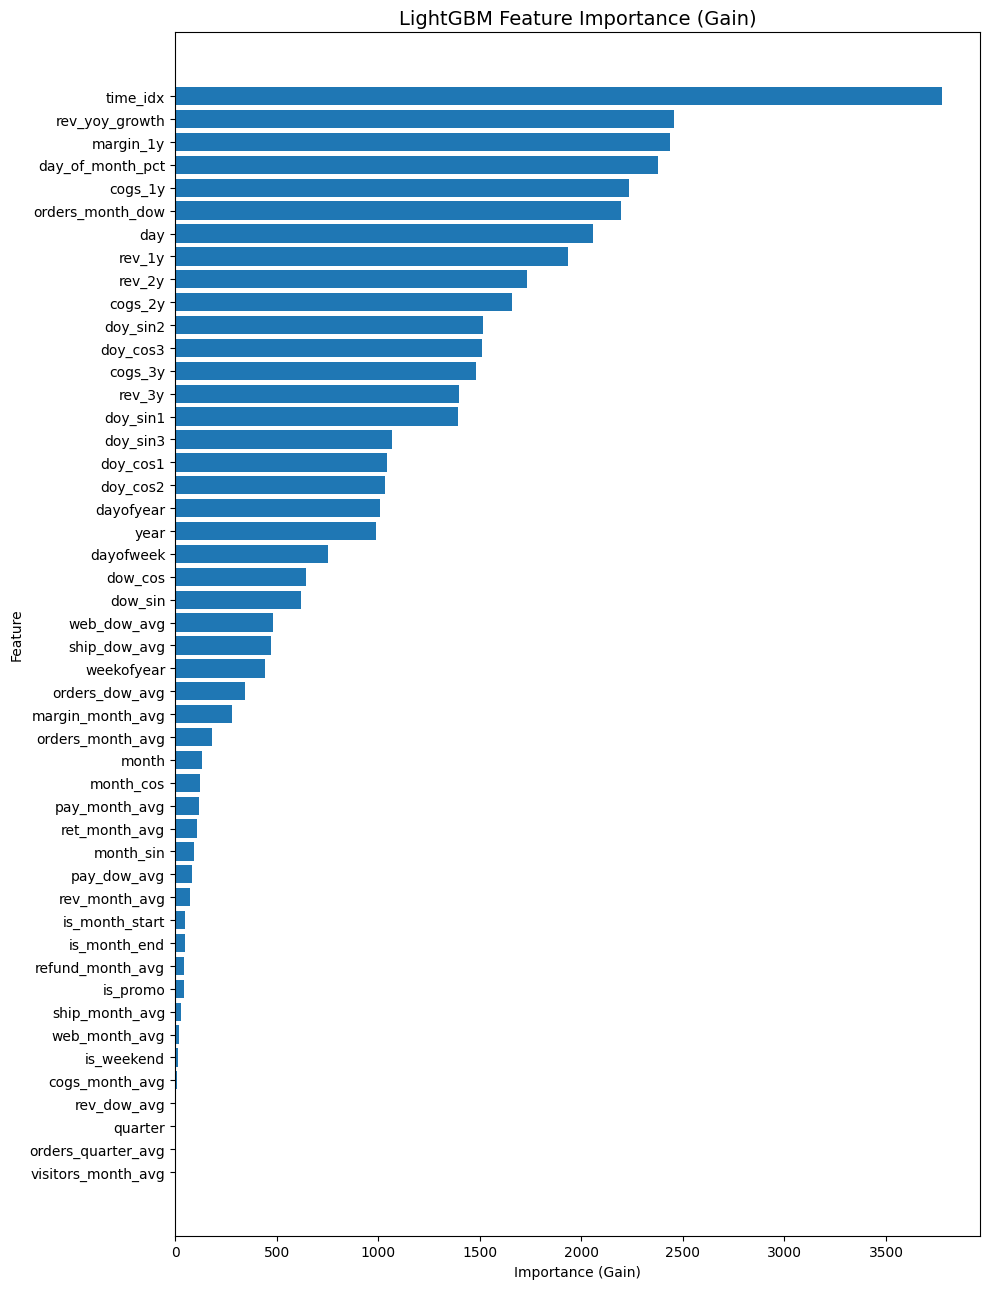


Top 15 Features:


,feature,importance
10,time_idx,3774
28,rev_yoy_growth,2454
29,margin_1y,2438
11,day_of_month_pct,2377
25,cogs_1y,2234
33,orders_month_dow,2196
2,day,2058
22,rev_1y,1936
23,rev_2y,1732
26,cogs_2y,1657



Bottom 5 Features (it quan trong nhat):


,feature,importance
45,cogs_month_avg,10
44,rev_dow_avg,6
6,quarter,4
32,orders_quarter_avg,4
42,visitors_month_avg,3


In [14]:
# Train LGB on full data for importance analysis
import matplotlib.pyplot as plt

final_lgb = LGBMRegressor(n_estimators=800, learning_rate=0.02, max_depth=8,
    num_leaves=95, min_child_samples=15, subsample=0.75, colsample_bytree=0.75,
    reg_alpha=0.05, reg_lambda=1.5, random_state=SEED, verbose=-1, n_jobs=-1)
final_lgb.fit(X_full, np.log1p(y_rev))

imp = pd.DataFrame({"feature": feature_cols, "importance": final_lgb.feature_importances_})
imp = imp.sort_values("importance", ascending=False)

plt.figure(figsize=(10, 13))
plt.barh(imp["feature"].values[::-1], imp["importance"].values[::-1])
plt.title("LightGBM Feature Importance (Gain)", fontsize=14)
plt.xlabel("Importance (Gain)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("\nTop 15 Features:")
display(imp.head(15))
print("\nBottom 5 Features (it quan trong nhat):")
display(imp.tail(5))

### 7.2. SHAP Values Analysis

SHAP (SHapley Additive exPlanations) cho biết mỗi feature đóng góp bao nhiêu vào dự báo của từng sample.

- **Đỏ**: Feature tăng Revenue prediction
- **Xanh**: Feature giảm Revenue prediction
- Features ở trên có impact lớn hơn features ở dưới

In [15]:
try:
    import shap
    explainer = shap.TreeExplainer(final_lgb)
    sample_X = X_full.sample(500, random_state=42)
    shap_vals = explainer.shap_values(sample_X)

    plt.figure(figsize=(10, 13))
    shap.summary_plot(shap_vals, sample_X, feature_names=feature_cols, show=False)
    plt.title("SHAP Summary Plot - Feature Impact on Revenue Prediction")
    plt.tight_layout()
    plt.show()
    print("SHAP analysis completed successfully")
except ImportError:
    print("Thu vien shap chua duoc cai dat.")
    print("Cai dat bang: pip install shap")
    print("Feature importance (gain-based) da duoc hien thi o tren.")

Thu vien shap chua duoc cai dat.
Cai dat bang: pip install shap
Feature importance (gain-based) da duoc hien thi o tren.


## 8. Tổng kết

### 8.1. Tuân thủ ràng buộc

| Ràng buộc | Trạng thái | Chi tiết |
|-----------|-----------|---------|
| Không dùng Revenue/COGS từ test làm feature | ✅ Đã tuân thủ | Chỉ dùng features từ Date + historical train values |
| Không dùng dữ liệu ngoài | ✅ Đã tuân thủ | Chỉ dùng datasets được cung cấp trong data/ |
| Mã nguồn tái lập được | ✅ Đã tuân thủ | SEED=42 cố định, deterministic pipeline |

### 8.2. Kết quả

- **Cross-validation**: 10-fold TimeSeriesSplit, OOF MAE được báo cáo ở Section 4 và 5
- **Kaggle Public Score**: ~707k MAE

### 8.3. Các điểm mạnh của pipeline

1. **Non-recursive forecasting**: Dự báo trực tiếp từ features, tránh tích lũy lỗi qua 548 ngày
2. **50 features từ 7 nguồn dữ liệu**: Kết hợp time features, historical patterns và auxiliary seasonal
3. **5-model ensemble + Ridge stacking**: Tăng robustness, giảm variance
4. **10-fold Time-Series CV**: Đánh giá mô hình nghiêm ngặt, không data leakage
5. **SHAP/Feature importance**: Giải thích được mô hình đang học gì

### 8.4. Key Insights

- **Historical Revenue cùng kỳ năm trước** (`rev_1y`, `rev_2y`) là features quan trọng nhất
- **Seasonal patterns từ orders và payments** (corr > 0.93) đóng góp đáng kể
- **Cyclical features** giúp model hiểu được tính chu kỳ của revenue
- **Log transform** target giúp model học tốt hơn với outliers
- **Ridge stacking** tự động tìm trọng số tối ưu cho từng model